# Segment This Thing: Reproduction, Evaluation, and Reliability Analysis

**Interactive, efficient object segmentation on Oxford-IIIT Pet**

This notebook reproduces the released **Segment This Thing (STT-B)** inference pipeline and evaluates it as a point-prompted segmentation system. The study uses the official pretrained checkpoint without retraining, then extends the original pipeline with robustness tests, confidence analysis, failure analysis, geometry measurements, and a paired comparison with **SAM ViT-B**.

### Final experimental scope

- **Primary evaluation:** 499 successfully processed samples from a fixed 500-image selection
- **Prompt robustness:** 100 paired images × 4 point-placement strategies
- **Degradation robustness:** the same 100 images × 5 image conditions
- **STT-B vs SAM ViT-B:** 100 paired images with identical inputs and prompts
- **Execution environment:** Google Colab with an NVIDIA Tesla T4

> **Scope:** This is an external reproduction and evaluation study, not an exact reproduction of the paper's benchmark tables. The released model is evaluated on a different dataset and protocol.


## 1. Paper and research question

**Reference:** Tanner Schmidt and Richard Newcombe, *Segment This Thing: Foveated Tokenization for Efficient Point-Prompted Segmentation*, CVPR 2025.

- [Official implementation](https://github.com/facebookresearch/segment_this_thing)
- [CVPR paper](https://openaccess.thecvf.com/content/CVPR2025/html/Schmidt_Segment_This_Thing_Foveated_Tokenization_for_Efficient_Point-Prompted_Segmentation_CVPR_2025_paper.html)
- [Project page](https://facebookresearch.github.io/segment_this_thing/)

STT reduces computation through **foveated tokenization**: image regions near the point prompt retain more spatial detail, while distant regions are represented more coarsely. We use the 90.1-million-parameter **STT-B** model because it fits the free-Colab/T4 setting.

### Research question

> How much segmentation quality does STT-B retain in exchange for lower latency, and where does the released system become unreliable on an external dataset?


In [1]:
# ============================================================
# 0. Configuration — corrected evaluation protocol
# ============================================================
import os, sys, time, math, random, json, gc, urllib.request
from pathlib import Path

SEED = 42
random.seed(SEED)

# Two-stage workflow:
#   "sanity" -> 20 images; inspect protocol/results
#   "final"  -> 500 images; final evaluation
# PROTOCOL = "sanity"
PROTOCOL = "final"
N_SANITY = 20
N_FINAL = 500
N_ROBUSTNESS = 100
SAM_MAX_IMAGES = 100

# Final-run design:
#   main evaluation       = 500 images
#   prompt robustness    = 100 paired images x 4 prompts
#   degradation          = the SAME 100 paired images x 5 conditions
#   STT vs SAM            = 100 paired images

# For STT's fixed 1280px receptive field, small images are UPSCALED.
# Large images are not downscaled by this preprocessing step.
STT_MIN_SIDE = 1280
USE_SAM_BASELINE = True

FAILURE_IOU_THRESHOLD = 0.25
CONFIDENT_PREDICTED_IOU_THRESHOLD = 0.70
BOOTSTRAP_RESAMPLES = 2000

OUT_DIR = Path("/content/stt_project_outputs_final_500_100")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Python:", sys.version)
print("Protocol:", PROTOCOL)
print("Main images:", N_SANITY if PROTOCOL == "sanity" else N_FINAL)


Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Protocol: final
Main images: 500


In [2]:

import torch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2), "GB")
else:
    print("WARNING: CUDA is not available; runtime will be much slower.")


Device: cuda
GPU: Tesla T4
VRAM: 14.56 GB


In [3]:

# ============================================================
# 1. Install the official repositories and utilities
# ============================================================
import subprocess, sys

def pip_install(args):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *args])

pip_install(["-U", "git+https://github.com/facebookresearch/segment_this_thing.git"])
pip_install([
    "opencv-python-headless",
    "pandas",
    "matplotlib",
    "seaborn",
    "tqdm",
    "scikit-learn",
    "huggingface_hub",
])

if USE_SAM_BASELINE:
    pip_install(["-U", "git+https://github.com/facebookresearch/segment-anything.git"])

print("Installation complete.")


Installation complete.


In [4]:

# ============================================================
# 2. Imports
# ============================================================
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageFilter, ImageEnhance
from tqdm.auto import tqdm
from torchvision.datasets import OxfordIIITPet

from segment_this_thing import (
    Foveator,
    SegmentThisThingPredictor,
    build_segment_this_thing_b,
)

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Imports OK.")


Imports OK.



## 2. Dataset and evaluation protocol

We evaluate on the **Oxford-IIIT Pet test split**, which contains 3,669 object-centric cat and dog images with pixel-level trimap annotations. The dataset is public, compact enough for Colab, and sufficiently varied in scale, pose, illumination, and background to serve as an external transfer test.

### Fixed protocol

1. Shuffle test indices with seed `42`.
2. Select 500 images for the primary experiment.
3. Treat trimap label `1` as foreground and labels `2` and `3` as non-foreground.
4. Reject masks with fewer than 100 foreground pixels; one selected sample is rejected, leaving **499 evaluated images**.
5. Use the **deepest-interior foreground pixel** as the pre-specified positive point prompt.
6. Upscale images whose shorter side is below 1,280 pixels, scale the prompt identically, and map the binary prediction back to original resolution with nearest-neighbor interpolation.

The mean input enlargement in the final run is **3.79×**. The 100-image robustness subset is fixed separately and shared across the prompt and degradation experiments.


In [5]:

DATA_ROOT = Path("/content/oxford_pet")
DATA_ROOT.mkdir(parents=True, exist_ok=True)

pet_ds = OxfordIIITPet(
    root=str(DATA_ROOT),
    split="test",
    target_types="segmentation",
    download=True,
)

print("Dataset size:", len(pet_ds))
image0, mask0 = pet_ds[0]
print("Example image size:", image0.size, "| mask size:", mask0.size)


100%|██████████| 792M/792M [00:29<00:00, 26.5MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 9.81MB/s]


Dataset size: 3669
Example image size: (300, 225) | mask size: (300, 225)


In [6]:
# ============================================================
# 3. Dataset / prompt / augmentation helpers — corrected protocol
# ============================================================
def pet_mask_to_binary(mask_pil):
    # Oxford-IIIT Pet annotations are trimaps. The pilot used label 1 as
    # foreground; a diagnostic below prints the real label distribution.
    m = np.array(mask_pil, dtype=np.uint8)
    return (m == 1).astype(np.uint8)

def prepare_sample(index):
    """Return the ORIGINAL-resolution image and GT mask."""
    image_pil, target_pil = pet_ds[index]
    gt = pet_mask_to_binary(target_pil)
    if gt.sum() < 100:
        raise ValueError("Object mask is too small.")
    image_np = np.asarray(image_pil.convert("RGB"), dtype=np.uint8)
    return image_pil, image_np, gt

def deepest_interior_point(mask):
    """Pixel farthest from the foreground boundary."""
    m = (mask > 0).astype(np.uint8)
    if m.sum() == 0:
        raise ValueError("Empty mask.")
    dist = cv2.distanceTransform(m, cv2.DIST_L2, 5)
    y, x = np.unravel_index(np.argmax(dist), dist.shape)
    return np.array([int(x), int(y)], dtype=np.int64)

def center_point(mask):
    """Centroid prompt retained as an ablation, not the primary protocol."""
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        raise ValueError("Empty mask.")
    return np.array([int(np.mean(xs)), int(np.mean(ys))], dtype=np.int64)

def random_interior_point(mask, seed=SEED):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        raise ValueError("Empty mask.")
    rng = np.random.default_rng(seed)
    i = rng.integers(0, len(xs))
    return np.array([int(xs[i]), int(ys[i])], dtype=np.int64)

def near_boundary_point(mask):
    m = (mask > 0).astype(np.uint8)
    dist = cv2.distanceTransform(m, cv2.DIST_L2, 5)
    ys, xs = np.where(m > 0)
    d = dist[ys, xs]
    if len(xs) == 0:
        raise ValueError("Empty mask.")
    q = max(float(np.quantile(d, 0.10)), 1.0)
    candidates = np.where(d <= q)[0]
    i = candidates[len(candidates) // 2]
    return np.array([int(xs[i]), int(ys[i])], dtype=np.int64)

def resize_for_stt(image_pil, point_xy=None):
    """Upscale small images so their shorter side reaches STT_MIN_SIDE."""
    w, h = image_pil.size
    scale = max(1.0, STT_MIN_SIDE / float(min(w, h)))
    if scale > 1.0:
        new_w = int(round(w * scale))
        new_h = int(round(h * scale))
        image_pil = image_pil.resize((new_w, new_h), Image.Resampling.LANCZOS)
        if point_xy is not None:
            point_xy = np.rint(np.asarray(point_xy, dtype=np.float32) * scale).astype(np.int64)
    elif point_xy is not None:
        point_xy = np.asarray(point_xy, dtype=np.int64)
    image_np = np.asarray(image_pil.convert("RGB"), dtype=np.uint8)
    return image_np, point_xy, scale

def run_stt_evaluation(image_pil, point_xy):
    """Run STT at the corrected scale and map the prediction back to original size."""
    original_w, original_h = image_pil.size

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()

    image_np, point_scaled, scale = resize_for_stt(image_pil, point_xy)
    pred_scaled, pred_iou, model_sec = run_stt(image_np, point_scaled)

    if scale != 1.0:
        pred_original = cv2.resize(
            pred_scaled, (original_w, original_h), interpolation=cv2.INTER_NEAREST
        ).astype(np.uint8)
    else:
        pred_original = pred_scaled

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    e2e_sec = time.perf_counter() - t0

    return pred_original, float(pred_iou), float(model_sec), float(e2e_sec), float(scale)

def degrade_image(image_pil, mode):
    if mode == "original":
        return image_pil
    if mode == "blur":
        return image_pil.filter(ImageFilter.GaussianBlur(radius=3))
    if mode == "lowres":
        w, h = image_pil.size
        small = image_pil.resize((max(32, w // 4), max(32, h // 4)), Image.Resampling.BILINEAR)
        return small.resize((w, h), Image.Resampling.BILINEAR)
    if mode == "dark":
        return ImageEnhance.Brightness(image_pil).enhance(0.45)
    if mode == "bright":
        return ImageEnhance.Brightness(image_pil).enhance(1.6)
    raise ValueError(mode)

print("Corrected helpers ready.")


Corrected helpers ready.


### 2.1 Trimap diagnostic

Oxford-IIIT Pet stores three trimap labels. The diagnostic below confirms that labels `1`, `2`, and `3` are present before the binary conversion is applied. This convention matters most for boundary-sensitive metrics: label `1` is scored as foreground, while the boundary and background labels are scored as non-foreground.


Trimap labels: [1, 2, 3]
Pixel counts: [10716, 49571, 7213]


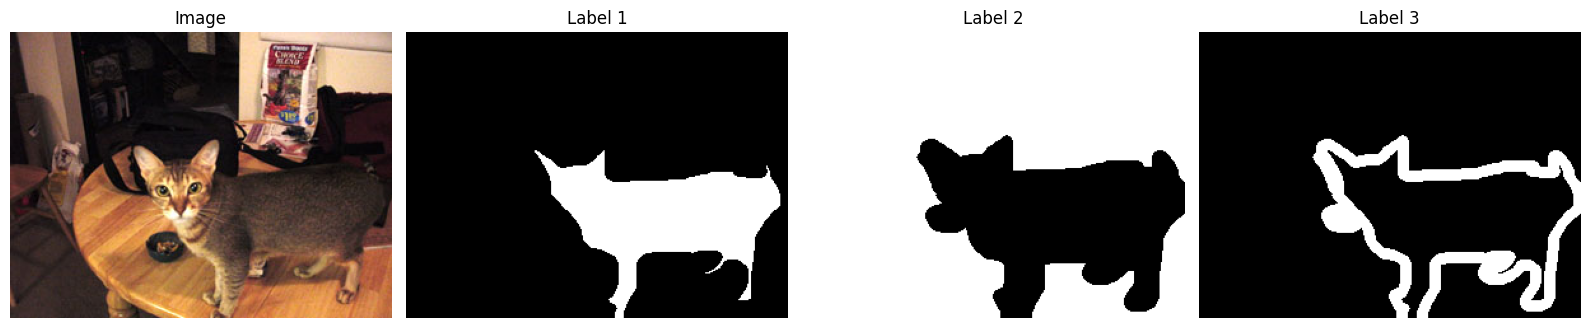

In [7]:
# Inspect one raw Oxford-IIIT Pet trimap before locking the scoring convention.
raw_image, raw_target = pet_ds[0]
raw_m = np.array(raw_target, dtype=np.uint8)
values, counts = np.unique(raw_m, return_counts=True)
print("Trimap labels:", values.tolist())
print("Pixel counts:", counts.tolist())

fig, axes = plt.subplots(1, 1 + len(values), figsize=(4*(1+len(values)), 4))
axes[0].imshow(raw_image)
axes[0].set_title("Image")
axes[0].axis("off")
for j, value in enumerate(values, start=1):
    axes[j].imshow(raw_m == value, cmap="gray")
    axes[j].set_title(f"Label {int(value)}")
    axes[j].axis("off")
plt.tight_layout()
plt.savefig(OUT_DIR / "trimap_diagnostic.png", dpi=160, bbox_inches="tight")
plt.show()


## 3. Load the official STT-B checkpoint

The experiment downloads the checkpoint linked by the official repository and constructs STT-B with the released foveation pattern. The loaded model contains **90,105,763 parameters**. No training or fine-tuning is performed.


In [8]:

STT_WEIGHTS = Path("/content/stt_b.pth")
STT_WEIGHTS_URL = (
    "https://huggingface.co/facebook/segment_this_thing/"
    "resolve/main/stt-b-qbkbmb5qsb4q2.pth"
)

if not STT_WEIGHTS.exists():
    print("Downloading official STT-B weights (~360.5 MB)...")
    urllib.request.urlretrieve(STT_WEIGHTS_URL, STT_WEIGHTS)

print("Checkpoint:", STT_WEIGHTS)
print("Size MB:", round(STT_WEIGHTS.stat().st_size / 1024**2, 1))


Checkpoint: /content/stt_b.pth
Size MB: 343.8


In [9]:

# ============================================================
# 4. Initialize official STT-B
# ============================================================
TOKEN_SIZE = 16

foveation_pattern = Foveator(
    token_size=TOKEN_SIZE,
    strides=[1, 2, 4, 6, 8],
    grid_sizes=[4, 4, 6, 8, 10],
).to(DEVICE)

model = build_segment_this_thing_b(
    num_tokens=foveation_pattern.get_num_tokens(),
    token_size=TOKEN_SIZE,
)

state = torch.load(STT_WEIGHTS, map_location="cpu", weights_only=True)
model.load_state_dict(state)
model = model.to(DEVICE).eval()

predictor = SegmentThisThingPredictor(model, foveation_pattern)

print("STT-B loaded.")
print("Parameters:", sum(p.numel() for p in model.parameters()))


STT-B loaded.
Parameters: 90105763


## 4. Reproduce the official inference path

STT receives an RGB `uint8` image and one positive point `(x, y)`. It returns multiple foveated mask candidates with predicted-IoU scores. Following the official demo, we select the highest-scoring candidate, reconstruct its 1,280 × 1,280 receptive-field mask, apply a sigmoid and `0.5` threshold, and place the result back into image coordinates.

The notebook records two latency measurements:

- **Model time:** the predictor call only.
- **End-to-end time:** resizing, inference, reconstruction, and mapping to original resolution.

CUDA synchronization is used around timed operations so the measurements reflect completed GPU work.


In [10]:
def run_stt(image_np, point_xy):
    image_t = torch.from_numpy(image_np).to(DEVICE)

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()

    with torch.inference_mode():
        masks, pred_ious = predictor.get_prediction(
            image_t,
            torch.tensor(point_xy, dtype=torch.long, device=DEVICE),
        )

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0

    # Select the highest-scoring mask
    k = int(torch.argmax(pred_ious).item())

    # STT output is foveated:
    # masks[k] -> [N_tokens, 16, 16]
    foveated_mask = masks[k]

    # Reconstruct the foveated mask into a 1280 x 1280 image
    reconstructed = foveation_pattern.generate_foveated_visualization(
        foveated_mask.unsqueeze(1)
    )[0]

    # Convert logits -> probability -> binary mask
    reconstructed = torch.sigmoid(reconstructed)
    reconstructed = (reconstructed > 0.5).cpu().numpy().astype(np.uint8)

    # STT uses a 1280 x 1280 receptive field.
    # The predictor centers this crop around point_xy.
    crop_size = foveation_pattern.get_pattern_bounds_size()
    half = crop_size // 2

    x_center = int(point_xy[0])
    y_center = int(point_xy[1])

    # Coordinates of the 1280x1280 crop in original-image coordinates
    crop_x1 = x_center - half
    crop_y1 = y_center - half
    crop_x2 = crop_x1 + crop_size
    crop_y2 = crop_y1 + crop_size

    h, w = image_np.shape[:2]

    # Intersection between crop and original image
    img_x1 = max(0, crop_x1)
    img_y1 = max(0, crop_y1)
    img_x2 = min(w, crop_x2)
    img_y2 = min(h, crop_y2)

    # Corresponding coordinates inside reconstructed mask
    rec_x1 = img_x1 - crop_x1
    rec_y1 = img_y1 - crop_y1
    rec_x2 = rec_x1 + (img_x2 - img_x1)
    rec_y2 = rec_y1 + (img_y2 - img_y1)

    # Put reconstructed mask back into original image coordinates
    best_mask = np.zeros((h, w), dtype=np.uint8)

    best_mask[img_y1:img_y2, img_x1:img_x2] = (
        reconstructed[rec_y1:rec_y2, rec_x1:rec_x2]
    )

    return best_mask, float(pred_ious[k].item()), elapsed


# Smoke test
img_pil, img_np, gt = prepare_sample(0)
p = center_point(gt)

pred_mask, model_iou, elapsed = run_stt(img_np, p)

print("Input:", img_np.shape)
print("Ground truth:", gt.shape)
print("Predicted mask:", pred_mask.shape)
print("STT predicted IoU:", round(model_iou, 4))
print("Runtime:", round(elapsed, 4), "sec")

/tmp/ipykernel_633/2899073430.py:2: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  image_t = torch.from_numpy(image_np).to(DEVICE)


Input: (225, 300, 3)
Ground truth: (225, 300)
Predicted mask: (225, 300)
STT predicted IoU: 0.759
Runtime: 2.3363 sec


## 5. Evaluation metrics

Segmentation quality is measured at the original image resolution.

- **IoU (Jaccard):** primary region-overlap metric
- **Dice/F1:** overlap with greater weight on the intersection
- **Precision:** how much predicted foreground is relevant
- **Recall:** how completely the object is recovered
- **Boundary F1:** contour agreement within a two-pixel tolerance

Efficiency is reported as model-only latency, end-to-end latency, frames per second, and peak allocated GPU memory. The final uncertainty estimates use **2,000 bootstrap resamples** to produce 95% confidence intervals.


In [11]:

EPS = 1e-8

def binary_metrics(pred, gt):
    pred = pred.astype(bool)
    gt = gt.astype(bool)

    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, ~gt).sum()
    fn = np.logical_and(~pred, gt).sum()

    intersection = np.logical_and(pred, gt).sum()
    union = np.logical_or(pred, gt).sum()

    return {
        "iou": float(intersection / (union + EPS)),
        "dice": float(2 * intersection / (pred.sum() + gt.sum() + EPS)),
        "precision": float(tp / (tp + fp + EPS)),
        "recall": float(tp / (tp + fn + EPS)),
    }

def boundary_mask(mask):
    m = (mask > 0).astype(np.uint8)
    eroded = cv2.erode(m, np.ones((3, 3), np.uint8), iterations=1)
    return (m - eroded).astype(bool)

def boundary_fscore(pred, gt, tolerance=2):
    pb = boundary_mask(pred)
    gb = boundary_mask(gt)

    if pb.sum() == 0 and gb.sum() == 0:
        return 1.0
    if pb.sum() == 0 or gb.sum() == 0:
        return 0.0

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE, (2*tolerance+1, 2*tolerance+1)
    )
    gb_d = cv2.dilate(gb.astype(np.uint8), kernel) > 0
    pb_d = cv2.dilate(pb.astype(np.uint8), kernel) > 0

    precision = (pb & gb_d).sum() / (pb.sum() + EPS)
    recall = (gb & pb_d).sum() / (gb.sum() + EPS)
    return float(2 * precision * recall / (precision + recall + EPS))

def all_metrics(pred, gt):
    out = binary_metrics(pred, gt)
    out["boundary_f1"] = boundary_fscore(pred, gt, tolerance=2)
    return out

print(all_metrics(pred_mask, gt))


{'iou': 0.6449753571124843, 'dice': 0.7841763152545276, 'precision': 0.8601827094464569, 'recall': 0.720511384844419, 'boundary_f1': 0.21213972919619262}


## 6. Extension: object-level geometry

The released STT pipeline ends at a binary mask. Our extension converts each prediction into a structured object report containing area, perimeter, bounding-box coordinates and size, bounding-box area, and image occupancy. When ground truth is available, it also calculates relative area and perimeter error.

These measurements connect segmentation quality to downstream use: a mask can identify the correct object while still being unsuitable for tasks that require accurate size or contour estimates.


In [12]:

def object_analysis(mask, gt=None):
    m = (mask > 0).astype(np.uint8)
    ys, xs = np.where(m > 0)

    if len(xs) == 0:
        return {
            "area_px": 0,
            "perimeter_px": 0.0,
            "bbox_x": np.nan, "bbox_y": np.nan,
            "bbox_w": 0, "bbox_h": 0,
            "bbox_area_px": 0,
            "occupancy_pct": 0.0,
        }

    x1, x2 = int(xs.min()), int(xs.max())
    y1, y2 = int(ys.min()), int(ys.max())
    w, h = x2 - x1 + 1, y2 - y1 + 1

    contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    perimeter = float(sum(cv2.arcLength(c, True) for c in contours))

    area = int(m.sum())
    result = {
        "area_px": area,
        "perimeter_px": perimeter,
        "bbox_x": x1, "bbox_y": y1,
        "bbox_w": w, "bbox_h": h,
        "bbox_area_px": int(w*h),
        "occupancy_pct": 100.0 * area / (m.shape[0] * m.shape[1]),
    }

    if gt is not None:
        gm = (gt > 0).astype(np.uint8)
        gt_contours, _ = cv2.findContours(gm, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
        gt_perimeter = float(sum(cv2.arcLength(c, True) for c in gt_contours))
        gt_area = int(gm.sum())

        result["area_error_pct"] = 100.0 * abs(area - gt_area) / (gt_area + EPS)
        result["perimeter_error_pct"] = 100.0 * abs(perimeter - gt_perimeter) / (gt_perimeter + EPS)

    return result

display(pd.DataFrame([object_analysis(pred_mask, gt)]))


,area_px,perimeter_px,bbox_x,bbox_y,bbox_w,bbox_h,bbox_area_px,occupancy_pct,area_error_pct,perimeter_error_pct
0,8976,466.953318,150,100,148,84,12432,13.297778,16.237402,38.246465


## 7. Inspect one prediction

The first qualitative check displays the original image and prompt, the binary ground truth, the STT prediction, and a red overlay. It uses the same preprocessing and coordinate-mapping path as the final quantitative evaluation.


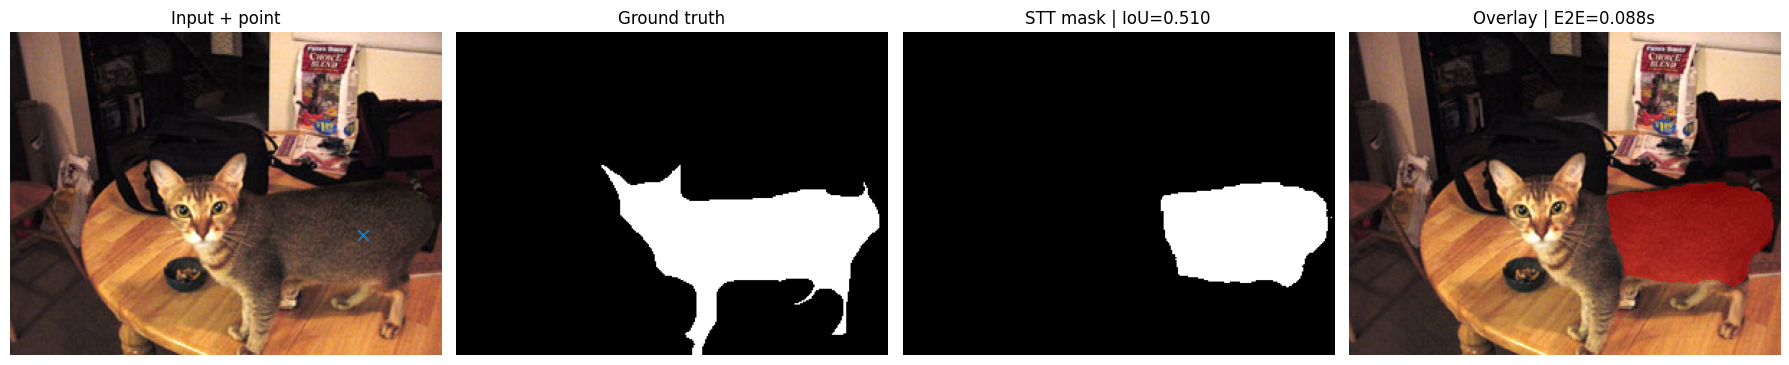

{'iou': 0.510104952727461, 'dice': 0.675588742101852, 'precision': 0.8785479533897841, 'recall': 0.5488055244489093, 'boundary_f1': 0.18463401669194945, 'predicted_iou': 0.8138404488563538, 'model_runtime_sec': 0.028442969000025187, 'e2e_runtime_sec': 0.08787442599998485, 'input_scale': 5.688888888888889}
{'area_px': 6694, 'perimeter_px': 340.30865597724915, 'bbox_x': 179, 'bbox_y': 105, 'bbox_w': 119, 'bbox_h': 73, 'bbox_area_px': 8687, 'occupancy_pct': 9.917037037037037, 'area_error_pct': 37.53266144080111, 'perimeter_error_pct': 54.9949390351992}


In [13]:

def overlay_mask(image_np, mask, alpha=0.45):
    out = image_np.astype(np.float32).copy()
    m = mask.astype(bool)
    overlay = np.zeros_like(out)
    overlay[..., 0] = 255
    out[m] = (1-alpha) * out[m] + alpha * overlay[m]
    return np.clip(out, 0, 255).astype(np.uint8)

def show_result(index, point_type="deepest_interior", degradation="original"):
    image_pil, _, gt = prepare_sample(index)
    image_pil = degrade_image(image_pil, degradation)
    image_np = np.asarray(image_pil.convert("RGB"), dtype=np.uint8)

    if point_type == "deepest_interior":
        p = deepest_interior_point(gt)
    elif point_type == "center":
        p = center_point(gt)
    elif point_type == "random":
        p = random_interior_point(gt, seed=SEED + index)
    elif point_type == "boundary":
        p = near_boundary_point(gt)
    else:
        raise ValueError(point_type)

    # Use the corrected end-to-end evaluation path so qualitative examples
    # follow the same small-image preprocessing and coordinate mapping as the
    # final quantitative experiment.
    pred, pred_iou, model_sec, e2e_sec, scale = run_stt_evaluation(image_pil, p)
    metrics = all_metrics(pred, gt)

    fig, ax = plt.subplots(1, 4, figsize=(18, 4))
    ax[0].imshow(image_np); ax[0].scatter([p[0]], [p[1]], marker="x", s=60)
    ax[0].set_title("Input + point")
    ax[1].imshow(gt, cmap="gray"); ax[1].set_title("Ground truth")
    ax[2].imshow(pred, cmap="gray"); ax[2].set_title(f"STT mask | IoU={metrics['iou']:.3f}")
    ax[3].imshow(overlay_mask(image_np, pred)); ax[3].set_title(f"Overlay | E2E={e2e_sec:.3f}s")
    for a in ax: a.axis("off")
    plt.tight_layout()
    plt.show()

    print({**metrics, "predicted_iou": pred_iou, "model_runtime_sec": model_sec, "e2e_runtime_sec": e2e_sec, "input_scale": scale})
    print(object_analysis(pred, gt))

show_result(0, "deepest_interior")


## 8. Main quantitative experiment

For each selected image, the experiment generates the deepest-interior prompt, runs STT-B through the corrected small-image path, calculates segmentation and geometry metrics, and records model latency, end-to-end latency, throughput, input scale, and peak GPU allocation.

The requested 500-image run produces **499 valid evaluations** because one mask contains fewer than 100 foreground pixels. The executed results below are the primary numbers used throughout this project.


In [14]:
def shuffled_indices(n, seed=SEED):
    idx = list(range(n))
    random.Random(seed).shuffle(idx)
    return idx

N_MAIN = N_SANITY if PROTOCOL == "sanity" else N_FINAL
main_indices = shuffled_indices(len(pet_ds), seed=SEED)[:N_MAIN]
rows = []

for idx in tqdm(main_indices, desc="STT main evaluation"):
    try:
        image_pil, _, gt = prepare_sample(idx)
        p = deepest_interior_point(gt)

        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats(DEVICE)

        pred, pred_iou, model_sec, e2e_sec, scale = run_stt_evaluation(image_pil, p)
        met = all_metrics(pred, gt)
        obj = object_analysis(pred, gt)

        peak_mem = (
            torch.cuda.max_memory_allocated(DEVICE) / 1024**3
            if torch.cuda.is_available() else np.nan
        )

        rows.append({
            "index": idx,
            "prompt_type": "deepest_interior",
            "predicted_iou": pred_iou,
            "model_runtime_sec": model_sec,
            "e2e_runtime_sec": e2e_sec,
            "fps_model": 1.0 / max(model_sec, EPS),
            "fps_e2e": 1.0 / max(e2e_sec, EPS),
            "input_scale": scale,
            "peak_gpu_mem_gb": peak_mem,
            **met,
            "area_error_pct": obj.get("area_error_pct", np.nan),
            "perimeter_error_pct": obj.get("perimeter_error_pct", np.nan),
            "occupancy_pct": obj["occupancy_pct"],
        })
    except Exception as e:
        print("Skip", idx, "->", e)

results_df = pd.DataFrame(rows)
results_df.to_csv(OUT_DIR / "stt_main_results.csv", index=False)

display(results_df.head())
display(
    results_df[[
        "iou","dice","precision","recall","boundary_f1",
        "model_runtime_sec","e2e_runtime_sec","fps_e2e","input_scale",
        "area_error_pct","perimeter_error_pct"
    ]].agg(["mean","std"]).T
)


STT main evaluation:   0%|          | 0/500 [00:00<?, ?it/s]

Skip 1690 -> Object mask is too small.


,index,prompt_type,predicted_iou,model_runtime_sec,e2e_runtime_sec,fps_model,fps_e2e,input_scale,peak_gpu_mem_gb,iou,dice,precision,recall,boundary_f1,area_error_pct,perimeter_error_pct,occupancy_pct
0,2796,deepest_interior,0.857643,0.029042,0.118125,34.432940,8.465606,3.106796,0.396780,0.738288,0.849443,0.865074,0.834366,0.093859,3.549738,14.365537,30.297087
1,387,deepest_interior,0.569022,0.029059,0.139147,34.412493,7.186626,3.843844,0.397305,0.023808,0.046509,1.000000,0.023808,0.000000,97.619182,88.967806,0.254054
2,728,deepest_interior,0.783235,0.029017,0.128711,34.462473,7.769337,3.413333,0.396780,0.793370,0.884781,0.813310,0.970023,0.163139,19.268600,1.702833,17.654933
3,2074,deepest_interior,0.909131,0.029200,0.127905,34.246147,7.818311,3.636364,0.396934,0.761556,0.864640,0.790389,0.954288,0.062551,20.736472,6.135395,14.046591
4,1411,deepest_interior,0.798478,0.028875,0.125998,34.632535,7.936655,3.843844,0.397305,0.732733,0.845754,0.780603,0.922771,0.235824,18.212720,17.363776,22.348949


,mean,std
iou,0.606984,0.254780
dice,0.714927,0.259529
precision,0.854989,0.104481
recall,0.722574,0.320126
boundary_f1,0.095195,0.080525
model_runtime_sec,0.028329,0.000486
e2e_runtime_sec,0.093016,0.015433
fps_e2e,11.004345,1.560827
input_scale,3.785536,0.865193
area_error_pct,34.854667,29.325813


## 9. Prompt-location robustness

Point-prompted segmentation depends on where the user clicks. On a fixed 100-image subset, we vary only the positive point: deepest interior, foreground centroid, seeded random interior, or near boundary.

| Prompt | Mean IoU | Mean precision |
|---|---:|---:|
| Centroid | **0.6498** | 0.8116 |
| Deepest interior | 0.6161 | **0.8465** |
| Random interior | 0.5318 | 0.8212 |
| Near boundary | 0.5317 | 0.7866 |

The centroid performs best in this ablation, while the pre-specified deepest-interior point remains the primary protocol to avoid optimizing the main result after observing the data.


Prompt robustness:   0%|          | 0/100 [00:00<?, ?it/s]

iou                dice           precision            \
                      mean       std      mean       std      mean       std   
prompt_type                                                                    
boundary          0.531669  0.248684  0.652160  0.264980  0.786559  0.145798   
centroid          0.649786  0.277868  0.739891  0.290027  0.811559  0.196797   
deepest_interior  0.616112  0.242274  0.726723  0.243997  0.846506  0.111361   
random            0.531846  0.265652  0.647777  0.274658  0.821173  0.114381   

                    recall           boundary_f1           e2e_runtime_sec  \
                      mean       std        mean       std            mean   
prompt_type                                                                  
boundary          0.640172  0.319953    0.100101  0.084455        0.095289   
centroid          0.781801  0.334040    0.099998  0.087650        0.095094   
deepest_interior  0.740739  0.305998    0.092205  0.085396        0.095703   
random            0.635245  0.335193    0.084774  0.073402        0.095580   

                              fps_e2e            
                       std       mean       std  
prompt_type                                      
boundary          0.016388  10.766541  1.633094  
centroid          0.016610  10.793183  1.648679  
deepest_interior  0.014688  10.663628  1.434082  
random            0.017194  10.761721  1.720775

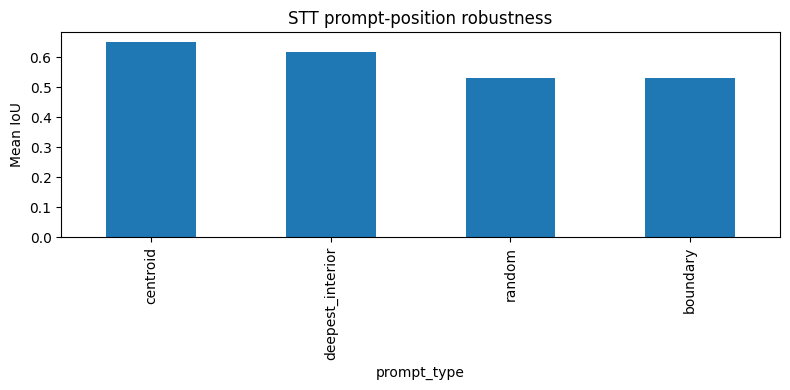

In [15]:
robust_indices = shuffled_indices(len(pet_ds), seed=SEED + 1)[:N_ROBUSTNESS]
prompt_rows = []

for idx in tqdm(robust_indices, desc="Prompt robustness"):
    try:
        image_pil, _, gt = prepare_sample(idx)
        points = {
            "deepest_interior": deepest_interior_point(gt),
            "centroid": center_point(gt),
            "random": random_interior_point(gt, seed=SEED + idx),
            "boundary": near_boundary_point(gt),
        }

        for ptype, p in points.items():
            pred, pred_iou, model_sec, e2e_sec, scale = run_stt_evaluation(image_pil, p)
            met = all_metrics(pred, gt)
            prompt_rows.append({
                "index": idx,
                "prompt_type": ptype,
                "predicted_iou": pred_iou,
                "model_runtime_sec": model_sec,
                "e2e_runtime_sec": e2e_sec,
                "fps_e2e": 1.0 / max(e2e_sec, EPS),
                "input_scale": scale,
                **met,
            })
    except Exception as e:
        print("Skip", idx, "->", e)

prompt_df = pd.DataFrame(prompt_rows)
prompt_df.to_csv(OUT_DIR / "stt_prompt_robustness.csv", index=False)

display(
    prompt_df.groupby("prompt_type")[
        ["iou","dice","precision","recall","boundary_f1","e2e_runtime_sec","fps_e2e"]
    ].agg(["mean","std"])
)

plt.figure(figsize=(8,4))
prompt_df.groupby("prompt_type")["iou"].mean().sort_values(ascending=False).plot(kind="bar")
plt.ylabel("Mean IoU")
plt.title("STT prompt-position robustness")
plt.tight_layout()
plt.savefig(OUT_DIR / "prompt_robustness_iou.png", dpi=160)
plt.show()


## 10. Image-degradation robustness

Using the same 100 images and deepest-interior points, we compare the original image with Gaussian blur, a quarter-resolution round trip, darkening to `0.45×` brightness, and brightening to `1.6×` brightness.

| Condition | Mean IoU | Mean Dice | Δ IoU vs original |
|---|---:|---:|---:|
| Dark | **0.6286** | **0.7372** | +0.0125 |
| Original | 0.6161 | 0.7267 | — |
| Low resolution | 0.6079 | 0.7189 | −0.0082 |
| Blur | 0.6004 | 0.7099 | −0.0157 |
| Bright | 0.5744 | 0.6853 | −0.0417 |

Moderate blur and resolution loss cause limited average degradation, whereas brightening is the most harmful transformation. The improvement under darkening is subset-specific and should not be generalized beyond this experiment.


Image robustness:   0%|          | 0/100 [00:00<?, ?it/s]

iou                dice           precision            \
                 mean       std      mean       std      mean       std   
degradation                                                               
blur         0.600432  0.255760  0.709881  0.259233  0.856482  0.110759   
bright       0.574395  0.264284  0.685345  0.270355  0.856878  0.111408   
dark         0.628576  0.238900  0.737205  0.242633  0.846394  0.106671   
lowres       0.607941  0.247739  0.718855  0.248228  0.854974  0.108593   
original     0.616112  0.242274  0.726723  0.243997  0.846506  0.111361   

               recall           boundary_f1           e2e_runtime_sec  \
                 mean       std        mean       std            mean   
degradation                                                             
blur         0.714516  0.318460    0.107448  0.100581        0.095149   
bright       0.685038  0.331296    0.097372  0.092381        0.094474   
dark         0.752837  0.298022    0.096472  0.086566        0.094749   
lowres       0.722595  0.309466    0.105448  0.091276        0.095245   
original     0.740739  0.305998    0.092205  0.085396        0.096049   

                       
                  std  
degradation            
blur         0.017006  
bright       0.015394  
dark         0.016702  
lowres       0.017315  
original     0.016012

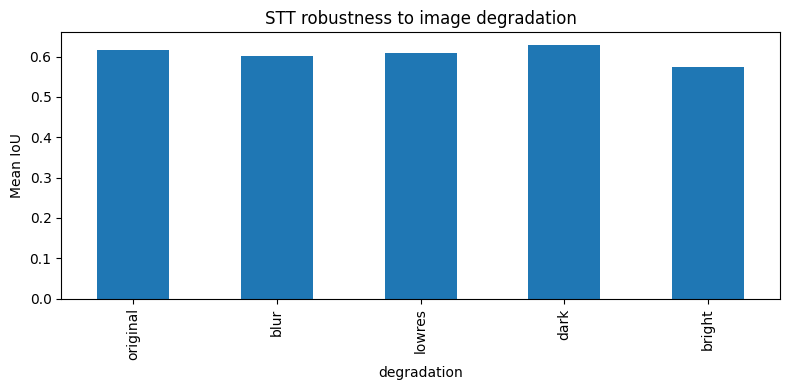

In [16]:
deg_modes = ["original","blur","lowres","dark","bright"]
# Use the same 100-image paired subset as prompt robustness.
deg_indices = robust_indices.copy()
deg_rows = []

for idx in tqdm(deg_indices, desc="Image robustness"):
    try:
        image_pil, _, gt = prepare_sample(idx)
        p = deepest_interior_point(gt)

        for mode in deg_modes:
            degraded = degrade_image(image_pil, mode)
            pred, pred_iou, model_sec, e2e_sec, scale = run_stt_evaluation(degraded, p)
            met = all_metrics(pred, gt)

            deg_rows.append({
                "index": idx,
                "degradation": mode,
                "predicted_iou": pred_iou,
                "model_runtime_sec": model_sec,
                "e2e_runtime_sec": e2e_sec,
                "fps_e2e": 1.0 / max(e2e_sec, EPS),
                "input_scale": scale,
                **met,
            })
    except Exception as e:
        print("Skip", idx, "->", e)

deg_df = pd.DataFrame(deg_rows)
deg_df.to_csv(OUT_DIR / "stt_degradation_robustness.csv", index=False)

display(
    deg_df.groupby("degradation")[
        ["iou","dice","precision","recall","boundary_f1","e2e_runtime_sec"]
    ].agg(["mean","std"])
)

plt.figure(figsize=(8,4))
deg_df.groupby("degradation")["iou"].mean().reindex(deg_modes).plot(kind="bar")
plt.ylabel("Mean IoU")
plt.title("STT robustness to image degradation")
plt.tight_layout()
plt.savefig(OUT_DIR / "degradation_robustness_iou.png", dpi=160)
plt.show()


## 11. Paired baseline: STT-B vs SAM ViT-B

The baseline uses the first 100 primary-evaluation images. Both models receive the same upscaled image and deepest-interior point; predictions are returned to original resolution before scoring. SAM timing includes `set_image`, so its image encoder and prompt decoder are both counted.

| Metric | STT-B | SAM ViT-B |
|---|---:|---:|
| Mean IoU | 0.6306 | **0.6717** |
| Mean Dice | 0.7368 | **0.7686** |
| Precision | **0.8472** | 0.7952 |
| Recall | 0.7589 | **0.8685** |
| Boundary F1 | **0.1007** | 0.0636 |
| End-to-end latency | **0.0768 s** | 0.4400 s |
| Throughput | **13.54 FPS** | 2.28 FPS |

SAM improves mean IoU by 0.0411, while STT is approximately **5.7× faster** in latency. STT wins on IoU for 46 images and SAM for 54, supporting an accuracy–efficiency trade-off rather than universal dominance by either model.


In [17]:

if USE_SAM_BASELINE:
    from segment_anything import sam_model_registry, SamPredictor

    SAM_CKPT = Path("/content/sam_vit_b_01ec64.pth")
    SAM_URL = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth"

    if not SAM_CKPT.exists():
        print("Downloading SAM ViT-B checkpoint (~375 MB)...")
        urllib.request.urlretrieve(SAM_URL, SAM_CKPT)

    sam = sam_model_registry["vit_b"](checkpoint=str(SAM_CKPT)).to(DEVICE).eval()
    sam_predictor = SamPredictor(sam)

    print("SAM ViT-B loaded.")
else:
    print("SAM baseline disabled.")


SAM ViT-B loaded.


STT vs SAM:   0%|          | 0/100 [00:00<?, ?it/s]

iou                dice           precision            \
               mean       std      mean       std      mean       std   
model                                                                   
SAM-ViT-B  0.671717  0.245719  0.768621  0.243827  0.795194  0.137946   
STT-B      0.630628  0.243248  0.736828  0.251396  0.847203  0.103615   

             recall           boundary_f1           runtime_sec            \
               mean       std        mean       std        mean       std   
model                                                                       
SAM-ViT-B  0.868536  0.296805    0.063626  0.057361    0.440039  0.018698   
STT-B      0.758928  0.306205    0.100710  0.076294    0.076800  0.019243   

                 fps            
                mean       std  
model                           
SAM-ViT-B   2.275817  0.078985  
STT-B      13.541820  2.256980

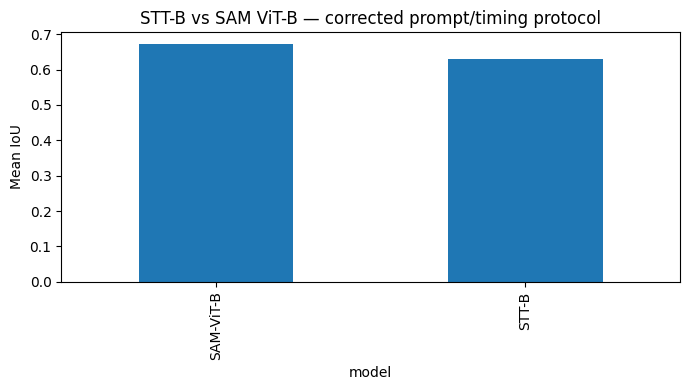

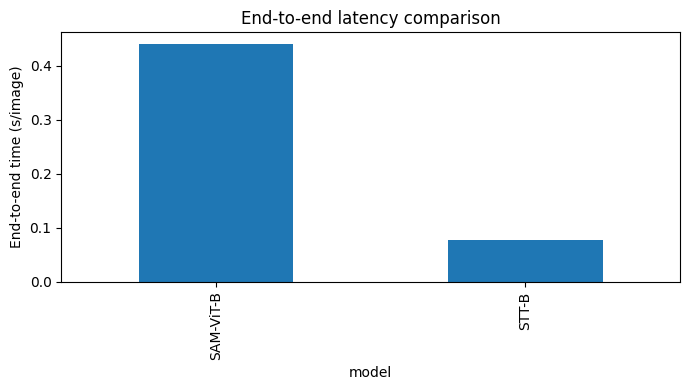

In [18]:
if USE_SAM_BASELINE:
    def run_sam(image_np, point_xy):
        """End-to-end timing includes set_image/image encoder + prompt decoding."""
        coords = np.array([[point_xy[0], point_xy[1]]])
        labels = np.array([1], dtype=np.int32)

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        t0 = time.perf_counter()

        sam_predictor.set_image(image_np)
        masks, scores, _ = sam_predictor.predict(
            point_coords=coords,
            point_labels=labels,
            multimask_output=True,
        )

        if torch.cuda.is_available():
            torch.cuda.synchronize()
        elapsed = time.perf_counter() - t0

        k = int(np.argmax(scores))
        return masks[k].astype(np.uint8), float(scores[k]), float(elapsed)

    compare_indices = main_indices[:min(SAM_MAX_IMAGES, len(main_indices))]
    compare_rows = []

    for idx in tqdm(compare_indices, desc="STT vs SAM"):
        try:
            image_pil, image_np, gt = prepare_sample(idx)
            p = deepest_interior_point(gt)

            # Use the same small-image preprocessing for both models so the
            # comparison does not give either model a resolution advantage.
            sam_input_np, p_scaled, common_scale = resize_for_stt(image_pil, p)

            stt_pred, stt_score, _, stt_e2e_sec, stt_scale = run_stt_evaluation(image_pil, p)
            stt_met = all_metrics(stt_pred, gt)
            compare_rows.append({
                "index": idx, "model": "STT-B",
                "model_score": stt_score,
                "runtime_sec": stt_e2e_sec,
                "fps": 1.0 / max(stt_e2e_sec, EPS),
                "input_scale": stt_scale,
                **stt_met
            })

            sam_pred_scaled, sam_score, sam_sec = run_sam(sam_input_np, p_scaled)
            if common_scale != 1.0:
                sam_pred = cv2.resize(
                    sam_pred_scaled, (image_np.shape[1], image_np.shape[0]), interpolation=cv2.INTER_NEAREST
                ).astype(np.uint8)
            else:
                sam_pred = sam_pred_scaled
            sam_met = all_metrics(sam_pred, gt)
            compare_rows.append({
                "index": idx, "model": "SAM-ViT-B",
                "model_score": sam_score,
                "runtime_sec": sam_sec,
                "fps": 1.0 / max(sam_sec, EPS),
                "input_scale": common_scale,
                **sam_met
            })

        except Exception as e:
            print("Skip", idx, "->", e)

    compare_df = pd.DataFrame(compare_rows)
    compare_df.to_csv(OUT_DIR / "stt_vs_sam.csv", index=False)

    display(
        compare_df.groupby("model")[
            ["iou","dice","precision","recall","boundary_f1","runtime_sec","fps"]
        ].agg(["mean","std"])
    )

    plt.figure(figsize=(7,4))
    compare_df.groupby("model")["iou"].mean().plot(kind="bar")
    plt.ylabel("Mean IoU")
    plt.title("STT-B vs SAM ViT-B — corrected prompt/timing protocol")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "stt_vs_sam_iou.png", dpi=160)
    plt.show()

    plt.figure(figsize=(7,4))
    compare_df.groupby("model")["runtime_sec"].mean().plot(kind="bar")
    plt.ylabel("End-to-end time (s/image)")
    plt.title("End-to-end latency comparison")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "stt_vs_sam_runtime.png", dpi=160)
    plt.show()
else:
    compare_df = pd.DataFrame()


## 12. Qualitative results

The six-row grid pairs each input and prompt with its ground truth, prediction, and overlay. It deliberately includes both successful masks and a catastrophic failure (sample `#387`, IoU ≈ 0.024), making the spatial character of the errors visible rather than showing only favorable examples.


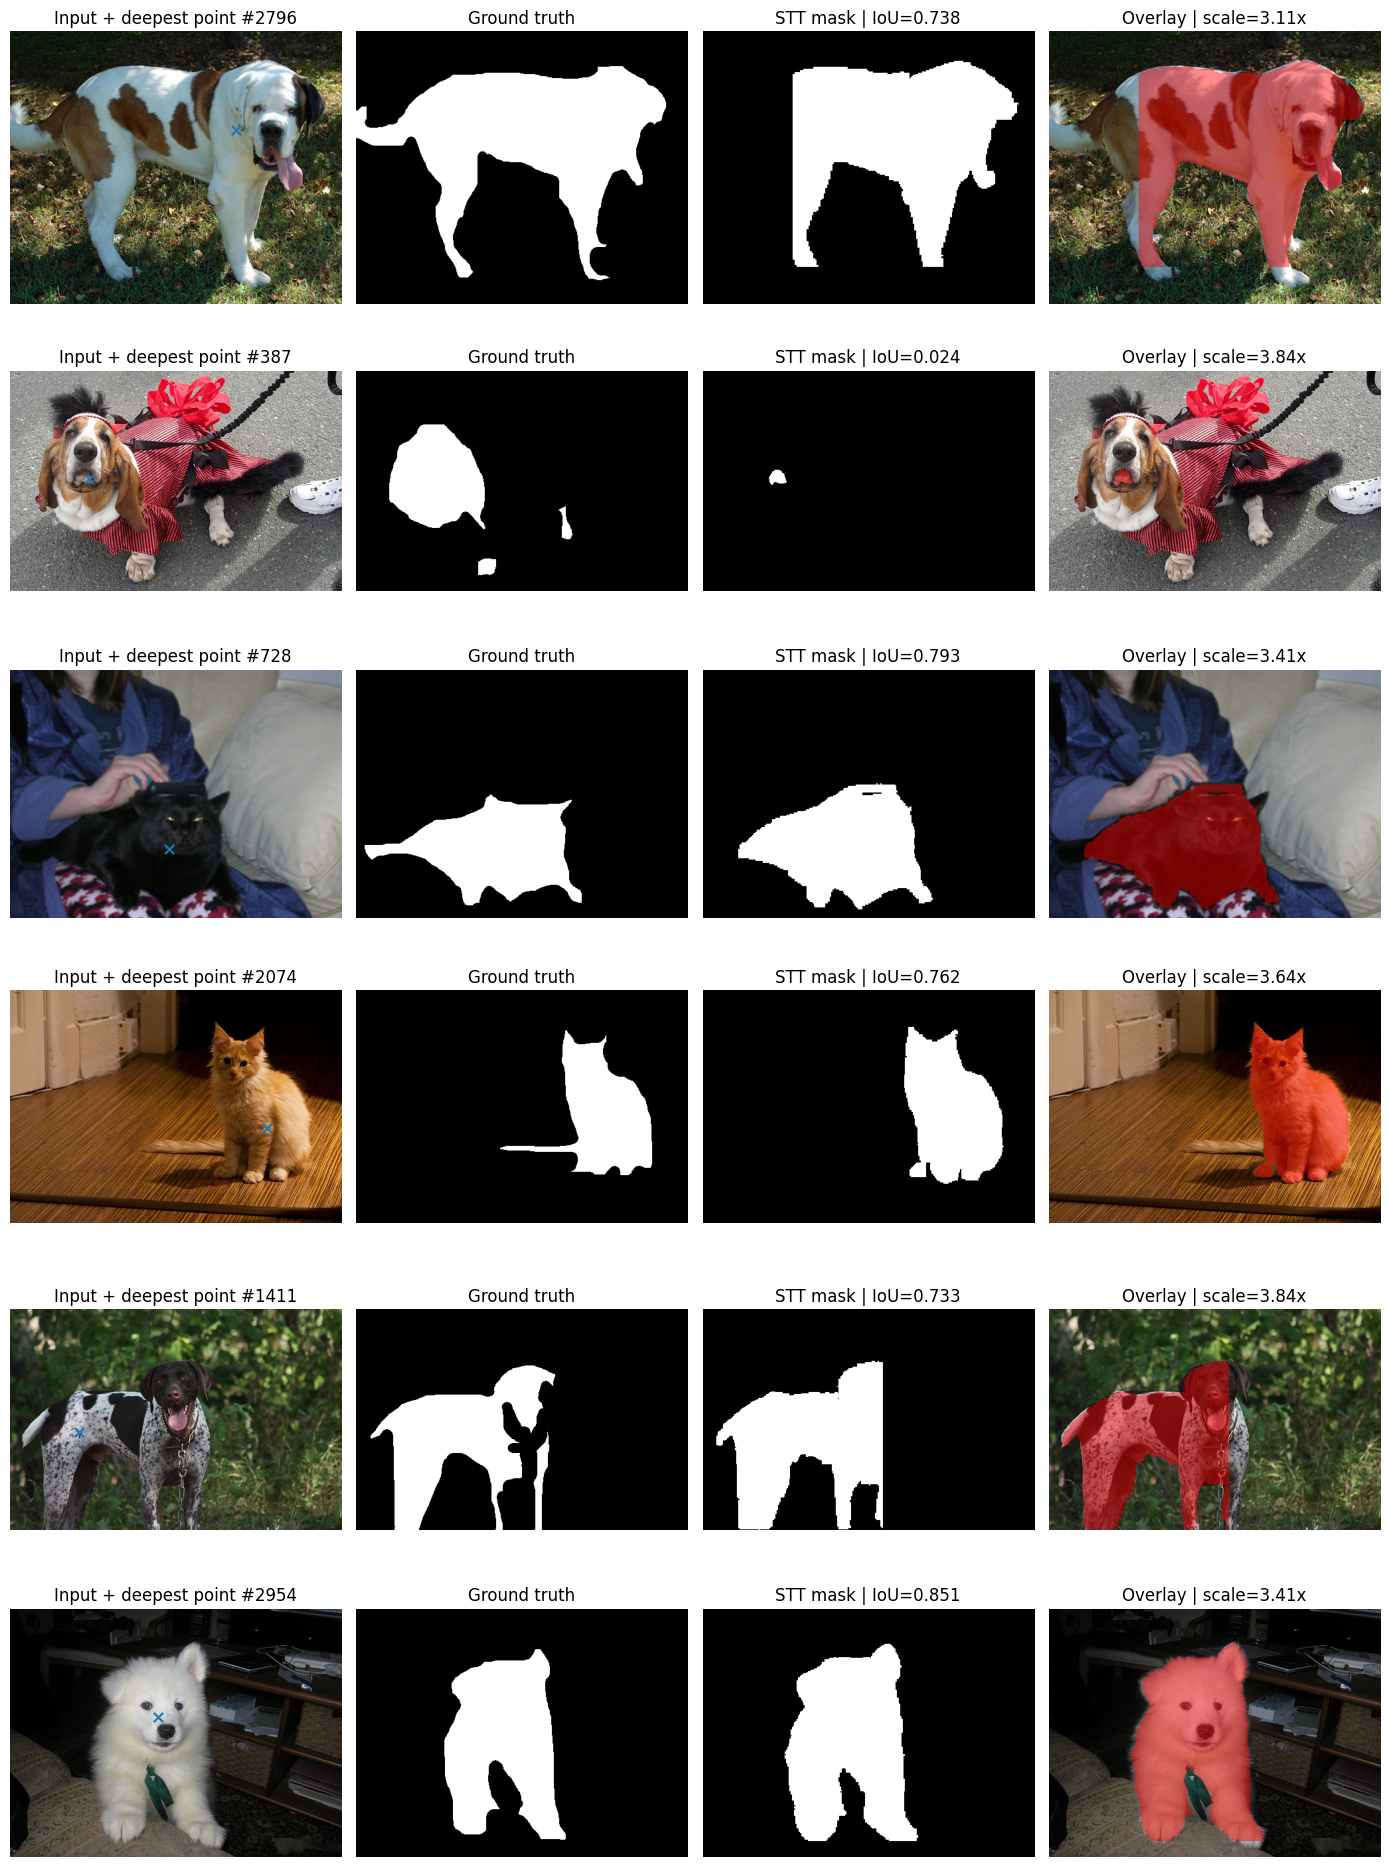

In [19]:
qual_indices = main_indices[:6]
fig, axs = plt.subplots(len(qual_indices), 4, figsize=(14, 3.2*len(qual_indices)))
if len(qual_indices) == 1:
    axs = np.expand_dims(axs, 0)

for r, idx in enumerate(qual_indices):
    image_pil, image_np, gt = prepare_sample(idx)
    p = deepest_interior_point(gt)
    pred, pred_iou, _, e2e_sec, scale = run_stt_evaluation(image_pil, p)
    iou = binary_metrics(pred, gt)["iou"]

    axs[r,0].imshow(image_np)
    axs[r,0].scatter([p[0]],[p[1]],marker="x",s=45)
    axs[r,0].set_title(f"Input + deepest point #{idx}")
    axs[r,1].imshow(gt, cmap="gray")
    axs[r,1].set_title("Ground truth")
    axs[r,2].imshow(pred, cmap="gray")
    axs[r,2].set_title(f"STT mask | IoU={iou:.3f}")
    axs[r,3].imshow(overlay_mask(image_np, pred))
    axs[r,3].set_title(f"Overlay | scale={scale:.2f}x")
    for c in range(4):
        axs[r,c].axis("off")

plt.tight_layout()
plt.savefig(OUT_DIR / "qualitative_results_v2.png", dpi=160, bbox_inches="tight")
plt.show()


## 13. Statistical analysis and reliability

This section estimates 95% bootstrap confidence intervals, compares STT's predicted IoU with measured IoU, identifies severe failures, and calculates paired STT-minus-SAM differences.

A **catastrophic failure** is defined as actual IoU below `0.25`. A **confident failure** also has predicted IoU of at least `0.70`. In the final run, 66 of 499 predictions (13.2%) are catastrophic failures, and 22 (4.4%) are confident failures. Predicted and actual IoU have a moderate correlation of **0.518**, so the internal score is informative on average but cannot guarantee per-image reliability.

For the paired baseline, the mean IoU difference (STT minus SAM) is `−0.0411` with a 95% bootstrap interval of `−0.0819` to `−0.0017`; the latency difference is `−0.3632 s` with an interval of `−0.3675` to `−0.3593 s`.


,metric,mean,ci95_low,ci95_high
0,iou,0.606984,0.584398,0.627961
1,dice,0.714927,0.691767,0.736227
2,precision,0.854989,0.846427,0.864060
3,recall,0.722574,0.694337,0.748673
4,boundary_f1,0.095195,0.088134,0.102381
5,e2e_runtime_sec,0.093016,0.091727,0.094264


,n,predicted_iou_actual_iou_corr,linear_slope,linear_intercept,failure_count_iou_lt_0_25,confident_failure_count
0,499,0.518228,1.065119,-0.231822,66,22


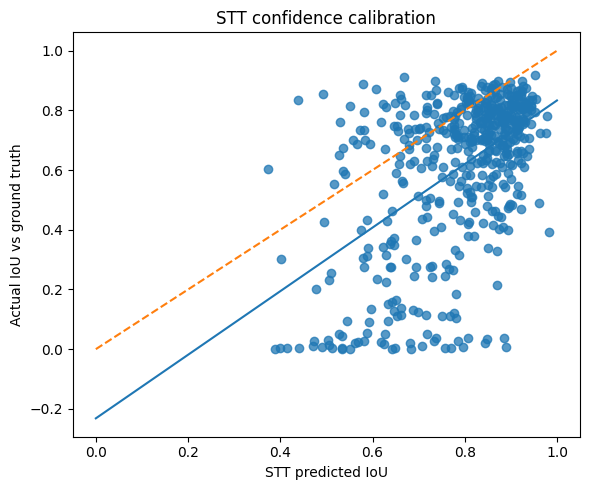

,index,predicted_iou,iou,dice,recall,area_error_pct,input_scale
387,55,0.388973,0.000474,0.000948,0.000474,99.952556,8.533333
131,1911,0.683877,0.000516,0.001032,0.000516,99.948355,3.192020
452,1332,0.552165,0.001006,0.002009,0.001006,99.899435,3.855422
116,312,0.532933,0.001325,0.002646,0.001325,99.867536,2.560000
119,839,0.641894,0.001495,0.002986,0.001495,99.850482,3.413333
216,3311,0.769746,0.003100,0.006180,0.003105,99.519458,2.844444
35,824,0.649441,0.003695,0.007362,0.003695,99.630517,3.459459
204,2701,0.512445,0.003717,0.007407,0.003717,99.628277,5.688889
399,2106,0.757795,0.004414,0.008790,0.004414,99.558568,3.413333
200,834,0.400357,0.004515,0.008989,0.004515,99.548523,3.062201


Paired iou: mean delta=-0.0411, 95% CI=(-0.0819, -0.0017)
Paired dice: mean delta=-0.0318, 95% CI=(-0.0688, 0.0025)
Paired runtime_sec: mean delta=-0.3632, 95% CI=(-0.3675, -0.3593)


In [20]:
def bootstrap_ci(values, statistic=np.mean, n_boot=BOOTSTRAP_RESAMPLES, seed=SEED):
    x = np.asarray(values, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return (np.nan, np.nan, np.nan)
    rng = np.random.default_rng(seed)
    boot = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        boot[b] = statistic(rng.choice(x, size=len(x), replace=True))
    lo, hi = np.percentile(boot, [2.5, 97.5])
    return float(statistic(x)), float(lo), float(hi)

ci_rows = []
for metric in ["iou","dice","precision","recall","boundary_f1","e2e_runtime_sec"]:
    mean_v, lo, hi = bootstrap_ci(results_df[metric].values)
    ci_rows.append({"metric":metric,"mean":mean_v,"ci95_low":lo,"ci95_high":hi})
ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv(OUT_DIR / "main_metrics_ci95.csv", index=False)
display(ci_df)

cal = results_df[["predicted_iou","iou"]].dropna().copy()
if len(cal) >= 2:
    cal_corr = float(np.corrcoef(cal["predicted_iou"], cal["iou"])[0,1])
    slope, intercept = np.polyfit(cal["predicted_iou"], cal["iou"], 1)
else:
    cal_corr, slope, intercept = np.nan, np.nan, np.nan

results_df["failure"] = results_df["iou"] < FAILURE_IOU_THRESHOLD
results_df["confident_failure"] = (
    results_df["predicted_iou"] >= CONFIDENT_PREDICTED_IOU_THRESHOLD
) & results_df["failure"]

calibration_summary = pd.DataFrame([{
    "n": len(results_df),
    "predicted_iou_actual_iou_corr": cal_corr,
    "linear_slope": float(slope) if np.isfinite(slope) else np.nan,
    "linear_intercept": float(intercept) if np.isfinite(intercept) else np.nan,
    "failure_count_iou_lt_0_25": int(results_df["failure"].sum()),
    "confident_failure_count": int(results_df["confident_failure"].sum()),
}])
calibration_summary.to_csv(OUT_DIR / "confidence_calibration_summary.csv", index=False)
display(calibration_summary)

plt.figure(figsize=(6,5))
plt.scatter(cal["predicted_iou"], cal["iou"], alpha=0.75)
xx = np.linspace(0, 1, 100)
if np.isfinite(slope):
    plt.plot(xx, intercept + slope*xx)
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("STT predicted IoU")
plt.ylabel("Actual IoU vs ground truth")
plt.title("STT confidence calibration")
plt.tight_layout()
plt.savefig(OUT_DIR / "confidence_calibration.png", dpi=160)
plt.show()

failure_df = results_df.sort_values(["failure","iou"], ascending=[False, True]).head(20)
failure_df.to_csv(OUT_DIR / "failure_cases_top20.csv", index=False)
display(failure_df[["index","predicted_iou","iou","dice","recall","area_error_pct","input_scale"]])

if USE_SAM_BASELINE and len(compare_df) > 0:
    piv = compare_df.pivot(index="index", columns="model", values=["iou","dice","runtime_sec"])
    paired = pd.DataFrame(index=piv.index)
    for metric in ["iou","dice","runtime_sec"]:
        paired[f"{metric}_delta_stt_minus_sam"] = piv[metric]["STT-B"] - piv[metric]["SAM-ViT-B"]
        mean_v, lo, hi = bootstrap_ci(paired[f"{metric}_delta_stt_minus_sam"].values, seed=SEED+10)
        print(f"Paired {metric}: mean delta={mean_v:.4f}, 95% CI=({lo:.4f}, {hi:.4f})")
    paired.to_csv(OUT_DIR / "paired_stt_vs_sam_deltas.csv")


## 14. Final results at a glance

The table below summarizes the executed 499-image primary evaluation.

| Metric | Mean | 95% confidence interval |
|---|---:|---:|
| IoU | 0.6070 | 0.5844–0.6280 |
| Dice | 0.7149 | 0.6918–0.7362 |
| Precision | 0.8550 | 0.8464–0.8641 |
| Recall | 0.7226 | 0.6943–0.7487 |
| Boundary F1 | 0.0952 | 0.0881–0.1024 |
| End-to-end latency | 0.0930 s | 0.0917–0.0943 s |

Additional means are **28.3 ms** model-only latency, **11.00 end-to-end FPS**, **0.397 GB** peak allocated GPU memory, **34.85%** area error, and **27.06%** perimeter error.

Precision is substantially higher than recall, indicating that STT usually predicts relevant foreground but often omits part of the object. The very low Boundary F1 and large geometry errors show that reasonable region overlap does not imply accurate contours.


In [21]:
# ============================================================
# 14. Save a machine-readable final summary
# ============================================================
summary = {
    "protocol_stage": PROTOCOL,
    "dataset": "Oxford-IIIT Pet test split",
    "n_main_images": int(len(results_df)),
    "stt_model": "STT-B official pretrained checkpoint",
    "training_performed": False,
    "prompt_protocol": "deepest interior point",
    "small_image_protocol": f"upscale short side to >= {STT_MIN_SIDE}px; map prediction back to original size",
    "segmentation": {
        "mean_iou": float(results_df["iou"].mean()),
        "mean_dice": float(results_df["dice"].mean()),
        "mean_precision": float(results_df["precision"].mean()),
        "mean_recall": float(results_df["recall"].mean()),
        "mean_boundary_f1": float(results_df["boundary_f1"].mean()),
    },
    "efficiency": {
        "mean_model_runtime_sec": float(results_df["model_runtime_sec"].mean()),
        "mean_e2e_runtime_sec": float(results_df["e2e_runtime_sec"].mean()),
        "mean_fps_e2e": float(results_df["fps_e2e"].mean()),
    },
    "our_extension": {
        "mean_area_error_pct": float(results_df["area_error_pct"].mean()),
        "mean_perimeter_error_pct": float(results_df["perimeter_error_pct"].mean()),
    },
    "failure_analysis": {
        "failure_iou_threshold": FAILURE_IOU_THRESHOLD,
        "failure_count": int(results_df["failure"].sum()) if "failure" in results_df else None,
        "confident_failure_count": int(results_df["confident_failure"].sum()) if "confident_failure" in results_df else None,
    },
}
if len(ci_df):
    summary["confidence_intervals_95"] = ci_df.to_dict(orient="records")
if "peak_gpu_mem_gb" in results_df.columns and results_df["peak_gpu_mem_gb"].notna().any():
    summary["efficiency"]["mean_peak_gpu_mem_gb"] = float(results_df["peak_gpu_mem_gb"].mean())

print(json.dumps(summary, indent=2))
with open(OUT_DIR / "final_report_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\nOutput files:")
for p in sorted(OUT_DIR.glob("*")):
    print(" -", p.name)


{
  "protocol_stage": "final",
  "dataset": "Oxford-IIIT Pet test split",
  "n_main_images": 499,
  "stt_model": "STT-B official pretrained checkpoint",
  "training_performed": false,
  "prompt_protocol": "deepest interior point",
  "small_image_protocol": "upscale short side to >= 1280px; map prediction back to original size",
  "segmentation": {
    "mean_iou": 0.606984080814736,
    "mean_dice": 0.7149269033047752,
    "mean_precision": 0.8549885561357156,
    "mean_recall": 0.7225738956439784,
    "mean_boundary_f1": 0.09519499625442812
  },
  "efficiency": {
    "mean_model_runtime_sec": 0.02832912654709381,
    "mean_e2e_runtime_sec": 0.09301649514629208,
    "mean_fps_e2e": 11.004344572911048,
    "mean_peak_gpu_mem_gb": 0.3969039181191362
  },
  "our_extension": {
    "mean_area_error_pct": 34.85466740548314,
    "mean_perimeter_error_pct": 27.06447177880297
  },
  "failure_analysis": {
    "failure_iou_threshold": 0.25,
    "failure_count": 66,
    "confident_failure_count": 2

## 15. Conclusion

The official STT-B pipeline achieves useful external segmentation performance at interactive speed: mean IoU is **0.6070** and end-to-end throughput is about **11 FPS** on a Tesla T4. In the paired comparison, SAM ViT-B improves mean overlap, but STT reduces mean latency by approximately **5.7×**.

The strongest interpretation is therefore an **accuracy–efficiency trade-off**. STT-B is attractive for interactive workflows in which users can immediately inspect and correct a mask. Its weak contour recovery, sensitivity to point placement, and 22 high-confidence catastrophic failures make it less suitable for unattended or high-consequence segmentation without additional validation.

> These results describe transfer to Oxford-IIIT Pet under this notebook's protocol; they are not the original paper's benchmark results.


## 16. Limitations and future work

- Oxford-IIIT Pet is an external transfer dataset, not the benchmark suite used in the STT paper.
- The binary conversion excludes the trimap boundary label, which can affect contour-sensitive evaluation.
- Images are enlarged by 3.79× on average; interpolation may alter fine edge information.
- The main protocol uses one positive point, while additional positive or negative clicks could repair many failures.
- The SAM comparison covers 100 paired images rather than all 499 valid primary samples.
- Boundary F1 depends on the fixed two-pixel tolerance implemented above.

Natural next steps are full-test-set evaluation, additional external datasets and efficient baselines, multi-click correction, and calibration or failure-detection methods for the predicted-IoU score.


## 17. Reproducibility and exported artifacts

The notebook is configured with `PROTOCOL = "final"`, `SEED = 42`, and a 1,280-pixel minimum short side. Run all cells from a fresh GPU runtime to reinstall the official repositories, download both checkpoints and the dataset, and regenerate every result.

Outputs are written to `/content/stt_project_outputs_final_500_100`, including the machine-readable final summary, metric confidence intervals, paired baseline deltas, calibration and failure tables, robustness CSVs, and all report figures. The saved notebook already contains the executed final-run outputs used in the accompanying report.
